C:\Users\andre\AppData\Local\Temp\ipykernel_19224\873613772.py:44: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  hvb_cashflows = pd.read_csv('data/cashflows_hvb.csv', parse_dates=['date'])


Running Credit Risk Simulation...
Running CDI Mandate Simulation...
Expected PV of Payment: 0.00


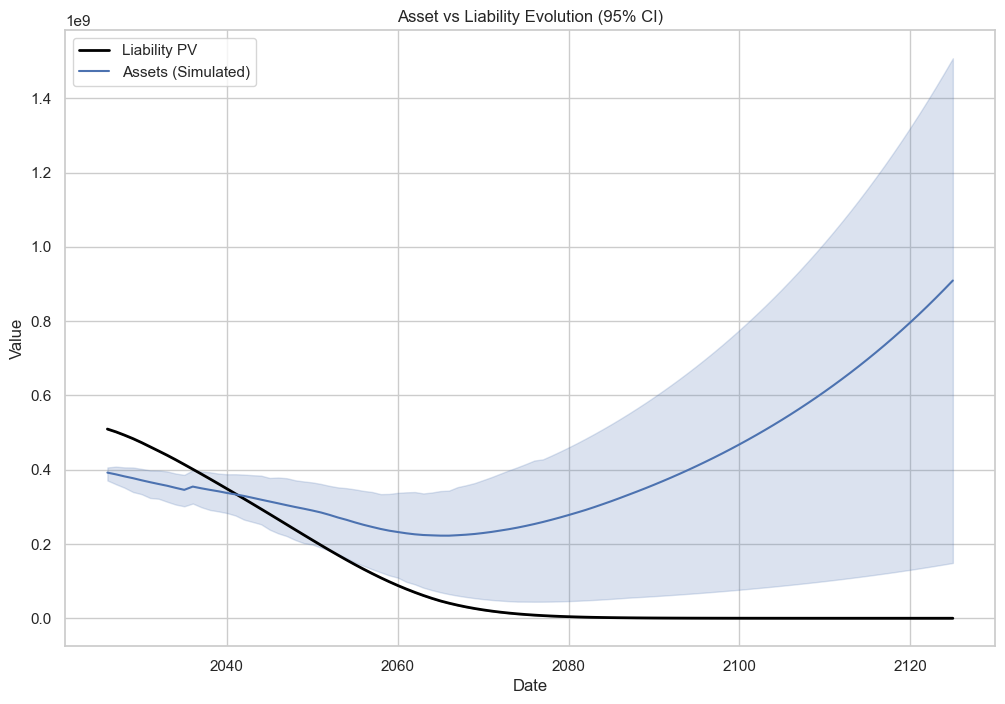

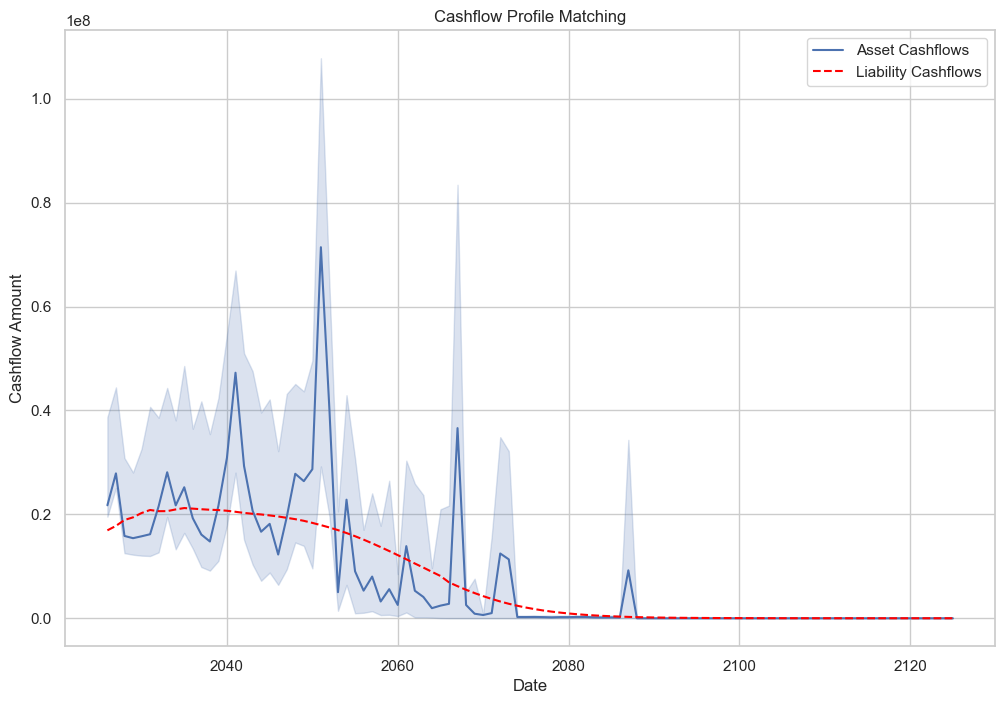

No payments triggered in any simulation.


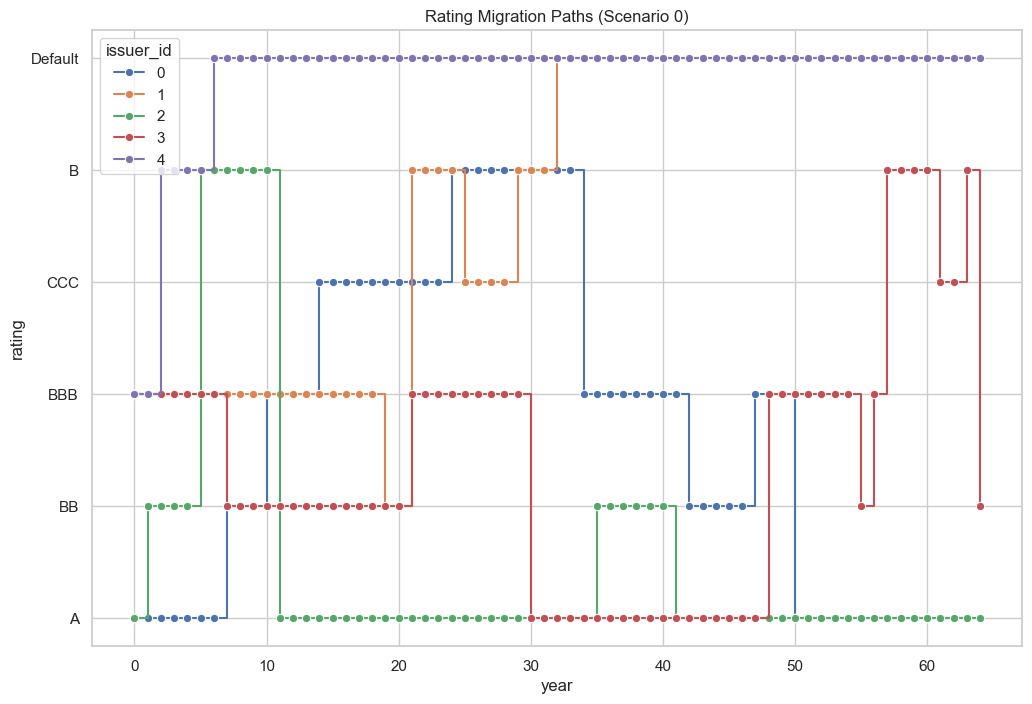

In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from utils import *

# ------------------------------------------------------------------------------
# 1. Data Ingestion
# ------------------------------------------------------------------------------

# --- A. Market Data ---
# Load Rates
try:
    yields_df = pd.read_csv('data/rates.csv', usecols=['date', 'yield'], parse_dates=['date'], dayfirst=True)
except (FileNotFoundError, ValueError) as e:
    print(f"Warning: Could not load rates.csv ({e}). Using dummy data.")
    dates = pd.date_range(start='2025-01-01', periods=100, freq='YE')
    yields_df = pd.DataFrame({'date': dates, 'yield': np.linspace(0.02, 0.04, 100)})

# Initialize Rates Object
val_date = pd.to_datetime('28-02-2025', dayfirst=True)
rates = Rates(data=yields_df)

# Spreads Map (Rating -> Spread)
spread_map = {"A": 0.02, "BBB": 0.03, "BB": 0.04, "B": 0.05, "CCC": 0.06, "Default": 0.0}


# --- B. Liabilities ---
try:
    liabilities_df = pd.read_csv('data/liabs.csv', usecols=['date', 'cashflow'], parse_dates=['date'], dayfirst=True)
except (FileNotFoundError, ValueError) as e:
    print(f"Warning: Could not load liabs.csv ({e}). Using dummy data.")
    dates = pd.date_range(start='2025-12-31', periods=65, freq='YE')
    cfs = np.linspace(20e6, 5e6, 65)
    liabilities_df = pd.DataFrame({'date': dates, 'cashflow': cfs})

liabilities = Liabilities(data=liabilities_df)


# --- C. Issuers and Bonds ---
try:
    issuers_df = pd.read_csv('data/issuers_hvb.csv', dtype={'id': 'str'}, usecols=['id', 'sector', 'rating'])
    hvb_bond_data = pd.read_csv('data/bonds_hvb.csv', usecols=['id', 'issuer_id', 'notional', 'recovery'], dtype={'id': 'str', 'issuer_id': 'str'})
    hvb_cashflows = pd.read_csv('data/cashflows_hvb.csv', parse_dates=['date']) 
    
    if 'date' in hvb_cashflows.columns:
         hvb_cashflows['date'] = pd.to_datetime(hvb_cashflows['date'])
         hvb_cashflows.set_index('date', inplace=True)
    
    hvb_cashflow_table = hvb_cashflows.resample('YE').sum().reset_index()

except (FileNotFoundError, ValueError) as e:
    print(f"Warning: Could not load bond data ({e}). Creating dummy portfolio.")
    # Dummy Issuers
    n_issuers = 10
    issuers_data = {
        'id': [str(i) for i in range(n_issuers)],
        'sector': np.random.choice(['Financials', 'Industrials', 'Utilities'], n_issuers),
        'rating': np.random.choice(['A', 'BBB', 'BB'], n_issuers)
    }
    issuers_df = pd.DataFrame(issuers_data)
    
    # Dummy Bonds
    hvb_bond_data = pd.DataFrame({
        'id': [f"bond_{i}" for i in range(n_issuers)],
        'issuer_id': [str(i) for i in range(n_issuers)],
        'notional': [10e6] * n_issuers,
        'recovery': [0.4] * n_issuers
    })
    
    # Dummy Cashflows (10 years)
    dates = pd.date_range(start='2025-12-31', periods=10, freq='YE')
    # Fix for Pylance dictionary type error: Create dict first, DF second, then add dates
    cf_data_dict = {f"bond_{i}": [500000] * 9 + [10500000] for i in range(n_issuers)}
    hvb_cashflow_table = pd.DataFrame(cf_data_dict)
    hvb_cashflow_table['date'] = dates

# Initialize Objects
issuers = Issuers(issuers_df)
bonds = Bonds(
    data=hvb_bond_data,
    cashflow_table=hvb_cashflow_table,
    issuers=issuers
)


# ------------------------------------------------------------------------------
# 2. Simulation Configuration
# ------------------------------------------------------------------------------

# --- Credit Risk Model Parameters ---
rho_e = 0.1
rho_s = np.array([0.2, 0.3, 0.25, 0.15]) 
if len(rho_s) < issuers.n_sectors:
    rho_s = np.pad(rho_s, (0, issuers.n_sectors - len(rho_s)), 'edge')

rating_labels = ['A', 'BBB', 'BB', 'B', 'CCC', 'Default']
t_matrix_vals = np.array([
    [0.90, 0.05, 0.03, 0.01, 0.005, 0.005], 
    [0.05, 0.85, 0.05, 0.03, 0.01, 0.01],   
    [0.01, 0.05, 0.85, 0.05, 0.03, 0.01],   
    [0.005,0.01, 0.05, 0.85, 0.05, 0.035],  
    [0.00, 0.005,0.01, 0.05, 0.85, 0.085],  
    [0.00, 0.00, 0.00, 0.00, 0.00, 1.00]    
])

transition_matrix = TransitionMatrix(tmatrix=t_matrix_vals, labels=rating_labels)

cr_model = CreditRiskModel(
    issuers=issuers,
    rho_e=rho_e,
    rho_s=rho_s,
    transition_matrix=transition_matrix
)

# --- CDI Mandate Parameters ---
gaap_int = 0.0201
mortality_buffer = 12.8e6
asset_buffer = np.linspace(12.5e6, 18e6, 65)

portfolio = Portfolio(
    asset_list=[bonds],
    allocations=[400e6]
)

cdi_fox = CDIMandate_Fox(
    liabilities=liabilities,
    portfolio=portfolio,
    cash=0,
    asset_buffer=asset_buffer,
    gaap_int=gaap_int,
    mortality_buffer=mortality_buffer
)


# ------------------------------------------------------------------------------
# 3. Execution
# ------------------------------------------------------------------------------
np.random.seed(42)
n_sim = 250
n_years = 65

print("Running Credit Risk Simulation...")
sim_results = cr_model.run(n_sim=n_sim, n_years=n_years)

print("Running CDI Mandate Simulation...")
cdi_results = cdi_fox.run(val_date, rates, spread_map, sim_results)

print(f"Expected PV of Payment: {cdi_results.expected_pv_payment:,.2f}")


# ------------------------------------------------------------------------------
# 4. Visualization
# ------------------------------------------------------------------------------
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 8]

# A. Assets vs Liabilities Overview
plt.figure()
sns.lineplot(data=cdi_results.cdi_results, x='date', y='liability_pvs', label='Liability PV', color='black', linewidth=2)
sns.lineplot(data=cdi_results.cdi_results, x='date', y='assets', label='Assets (Simulated)', errorbar=('pi', 95))

plt.title("Asset vs Liability Evolution (95% CI)")
plt.ylabel("Value")
plt.xlabel("Date")
plt.legend()
plt.show()

# B. Cashflow Profile
plt.figure()
if hasattr(cdi_results, 'bond_results'):
    bond_df = cdi_results.bond_results
    sns.lineplot(data=bond_df, x='date', y='cashflow', label='Asset Cashflows', errorbar=('pi', 95))
    
    # Fix for Pylance plotting error: Convert to numpy arrays explicitly
    liab_cfs = liabilities.cashflows.loc[val_date:]
    plt.plot(liab_cfs.index.to_numpy(), liab_cfs.to_numpy(), label='Liability Cashflows', color='red', linestyle='--')

    plt.title("Cashflow Profile Matching")
    plt.ylabel("Cashflow Amount")
    plt.xlabel("Date")
    plt.legend()
    plt.show()

# C. Payment Distribution
payments_df = cdi_results.cdi_results[cdi_results.cdi_results['payment'] > 0]

if not payments_df.empty:
    plt.figure()
    sns.histplot(data=payments_df, x='payment', bins=30, kde=True)
    plt.title("Distribution of Required Payments (Non-Zero Only)")
    plt.xlabel("Payment Amount")
    plt.show()
    
    plt.figure()
    sns.scatterplot(data=payments_df, x='date', y='payment', alpha=0.5)
    plt.title("Timing and Magnitude of Payments")
    plt.xlabel("Date")
    plt.ylabel("Payment Amount")
    plt.show()
else:
    print("No payments triggered in any simulation.")

# D. Credit Migration Visualization
transitions_df = sim_results.transitions_df
subset_issuers = issuers.ids[:5] 
subset_trans = transitions_df[(transitions_df['scenario'] == 0) & (transitions_df['issuer_id'].isin(subset_issuers))]

plt.figure()
sns.lineplot(data=subset_trans, x='year', y='rating', hue='issuer_id', marker="o", drawstyle='steps-post')
plt.title("Rating Migration Paths (Scenario 0)")
plt.gca().invert_yaxis() 
plt.show()

Running simulation...


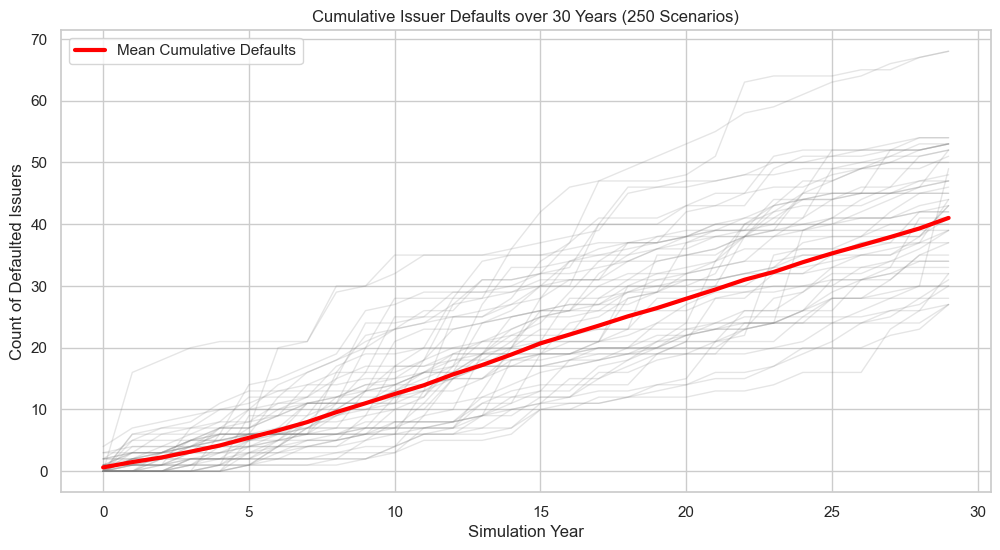

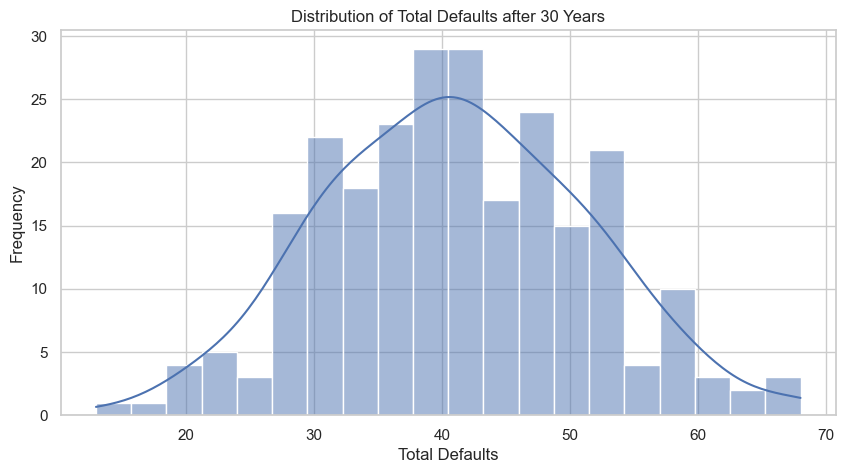

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from utils import *

# ------------------------------------------------------------------------------
# 1. Setup & Simulation (Data Loading)
# ------------------------------------------------------------------------------
# Load Rates (Dummy data fallback)
try:
    yields_df = pd.read_csv('data/rates.csv', usecols=['date', 'yield'], parse_dates=['date'], dayfirst=True)
except:
    dates = pd.date_range(start='2025-01-01', periods=100, freq='YE')
    yields_df = pd.DataFrame({'date': dates, 'yield': np.linspace(0.02, 0.04, 100)})
rates = Rates(data=yields_df)

# Load Issuers & Bonds (Dummy data fallback)
try:
    issuers_df = pd.read_csv('data/issuers_hvb.csv', dtype={'id': 'str'}, usecols=['id', 'sector', 'rating'])
except:
    issuers_df = pd.DataFrame({
        'id': [str(i) for i in range(100)],
        'sector': np.random.choice(['Financials', 'Industrials'], 100),
        'rating': np.random.choice(['A', 'BBB', 'BB'], 100)
    })
issuers = Issuers(issuers_df)

# Configuration
rho_e = 0.1
rho_s = np.array([0.2, 0.3]) 
if len(rho_s) < issuers.n_sectors:
    rho_s = np.pad(rho_s, (0, issuers.n_sectors - len(rho_s)), 'edge')

rating_labels = ['A', 'BBB', 'BB', 'B', 'CCC', 'Default']
t_matrix_vals = np.array([
    [0.90, 0.05, 0.03, 0.01, 0.005, 0.005], 
    [0.05, 0.85, 0.05, 0.03, 0.01, 0.01],   
    [0.01, 0.05, 0.85, 0.05, 0.03, 0.01],   
    [0.005,0.01, 0.05, 0.85, 0.05, 0.035],  
    [0.00, 0.005,0.01, 0.05, 0.85, 0.085],  
    [0.00, 0.00, 0.00, 0.00, 0.00, 1.00]    
])
transition_matrix = TransitionMatrix(tmatrix=t_matrix_vals, labels=rating_labels)

cr_model = CreditRiskModel(
    issuers=issuers,
    rho_e=rho_e,
    rho_s=rho_s,
    transition_matrix=transition_matrix
)

# Run Simulation
np.random.seed(42)
n_sim = 250
n_years = 30
print("Running simulation...")
sim_results = cr_model.run(n_sim=n_sim, n_years=n_years)

# ------------------------------------------------------------------------------
# 2. Process Default Data
# ------------------------------------------------------------------------------
# Extract transitions DataFrame
df = sim_results.transitions_df

# Filter for rows where rating is 'Default'
defaults = df[df['rating'] == 'Default'].copy()

if not defaults.empty:
    # Find the *first* year of default for each issuer in each scenario
    # (An issuer stays in Default once it enters, but we only want to count the event once)
    first_defaults = defaults.groupby(['scenario', 'issuer_id'])['year'].min().reset_index()

    # Count defaults per year per scenario
    # We create a pivot table to ensure we have 0s for years with no defaults
    defaults_by_year = first_defaults.groupby(['scenario', 'year']).size().reset_index(name='count')
    
    # Pivot to have years as columns to compute cumulative sum easily
    defaults_pivot = defaults_by_year.pivot(index='scenario', columns='year', values='count').fillna(0)
    
    # Reindex to ensure all years 0..n_years-1 are present
    defaults_pivot = defaults_pivot.reindex(columns=range(n_years), fill_value=0)
    
    # Calculate Cumulative Defaults
    cumulative_defaults = defaults_pivot.cumsum(axis=1)
    
    # Convert back to long format for plotting
    plot_data = cumulative_defaults.reset_index().melt(id_vars='scenario', var_name='year', value_name='cumulative_count')

    # Calculate statistics for the plot
    mean_defaults = cumulative_defaults.mean(axis=0)
    
    # ------------------------------------------------------------------------------
    # 3. Visualize
    # ------------------------------------------------------------------------------
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(12, 6))

    # Plot spaghetti lines for individual scenarios (light alpha)
    # Sampling 50 scenarios for readability if n_sim is large
    sample_scenarios = np.random.choice(cumulative_defaults.index, min(50, n_sim), replace=False)
    subset_data = plot_data[plot_data['scenario'].isin(sample_scenarios)]
    
    sns.lineplot(
        data=subset_data, 
        x='year', 
        y='cumulative_count', 
        units='scenario', 
        estimator=None, 
        color='grey', 
        alpha=0.2, 
        linewidth=1
    )

    # Plot the Mean trajectory
    # Fix: Explicitly convert Index and Series to numpy arrays for strict typing compliance
    plt.plot(
        mean_defaults.index.to_numpy(), 
        mean_defaults.to_numpy(), 
        color='red', 
        linewidth=3, 
        label='Mean Cumulative Defaults'
    )

    plt.title(f'Cumulative Issuer Defaults over {n_years} Years ({n_sim} Scenarios)')
    plt.xlabel('Simulation Year')
    plt.ylabel('Count of Defaulted Issuers')
    plt.legend()
    plt.show()
    
    # Histogram of Total Defaults at end of horizon
    plt.figure(figsize=(10, 5))
    final_defaults = cumulative_defaults.iloc[:, -1]
    
    # Fix: Pass final_defaults as keyword argument 'x' to avoid type ambiguity for 'data' param
    sns.histplot(x=final_defaults, kde=True, bins=20)
    
    plt.title(f'Distribution of Total Defaults after {n_years} Years')
    plt.xlabel('Total Defaults')
    plt.ylabel('Frequency')
    plt.show()

else:
    print("No defaults occurred in the simulation.")